<a href="https://colab.research.google.com/github/exoticmga/AlarmClock/blob/main/mod7_assign1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 7, Assignment 1: Introduction to Deep Learning with Tensorflow

In this Homework we will go through the basics of how to implement simple Deep Learning models in Python, from data preprocessing to the final evaluation and model improvements.

To do so, and for most of this notebook, we will work on an __image classification__ task. The goal here is to take raw images as input and have our model predict to which of several categories the image belongs.

You are going to solve this problem using Tensorflow. In case you want to give a try with Pytorch too, you can always use the Recitation Notebook as a good starter!



## Import Tensorflow related libraries

In [ ]:
# Import TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras

# We also import other necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import random

In [ ]:
# Set seeds for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Learning an Image Classification Model from Scratch





The [fashion_mnist](https://github.com/zalandoresearch/fashion-mnist) dataset is displayed below.

![Fashion MNIST](https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/doc/img/fashion-mnist-sprite.png)




<br>


### Accessing Keras datasets

Dataset creators typically (and helpfully!) split the data into training and test for us, taking care to ensure that they are as similar as possible.

For each of those two datasets, we have the features and the dependent variable (a.k.a target or label)  



In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

### First step with any new dataset: explore and visualize!

We are first exploring the size of the dataset.

In [ ]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)



We are printing the range of the data values in the training set.

In [ ]:
print(x_train[0].min())
print(x_train[0].max())

0
255


We now want to visualize how many different labels exist in the dataset, and match them with actual clothing items.

You can find information about the labels in the [Fashion MNIST Github site](https://github.com/zalandoresearch/fashion-mnist#labels).

In [ ]:
print(np.unique(y_train))

labels = ["T-shirt/top",
          "Trouser",
          "Pullover",
          "Dress",
          "Coat",
          "Sandal",
          "Shirt",
          "Sneaker",
          "Bag",
          "Ankle boot"]

print(labels[5])


[0 1 2 3 4 5 6 7 8 9]
Sandal


An important step during data exploration, is to visualize how many samples each class has, so that we can assess how balanced our dataset is.

In [ ]:
# Get unique values and their counts
unique_values, counts = np.unique(y_train, return_counts=True)

# Print results
for val, count in zip(unique_values, counts):
    print(f"Value {val} occurs {count} times")

Value 0 occurs 6000 times
Value 1 occurs 6000 times
Value 2 occurs 6000 times
Value 3 occurs 6000 times
Value 4 occurs 6000 times
Value 5 occurs 6000 times
Value 6 occurs 6000 times
Value 7 occurs 6000 times
Value 8 occurs 6000 times
Value 9 occurs 6000 times


We now visualize the first 25 images from the training set in a grid plot.


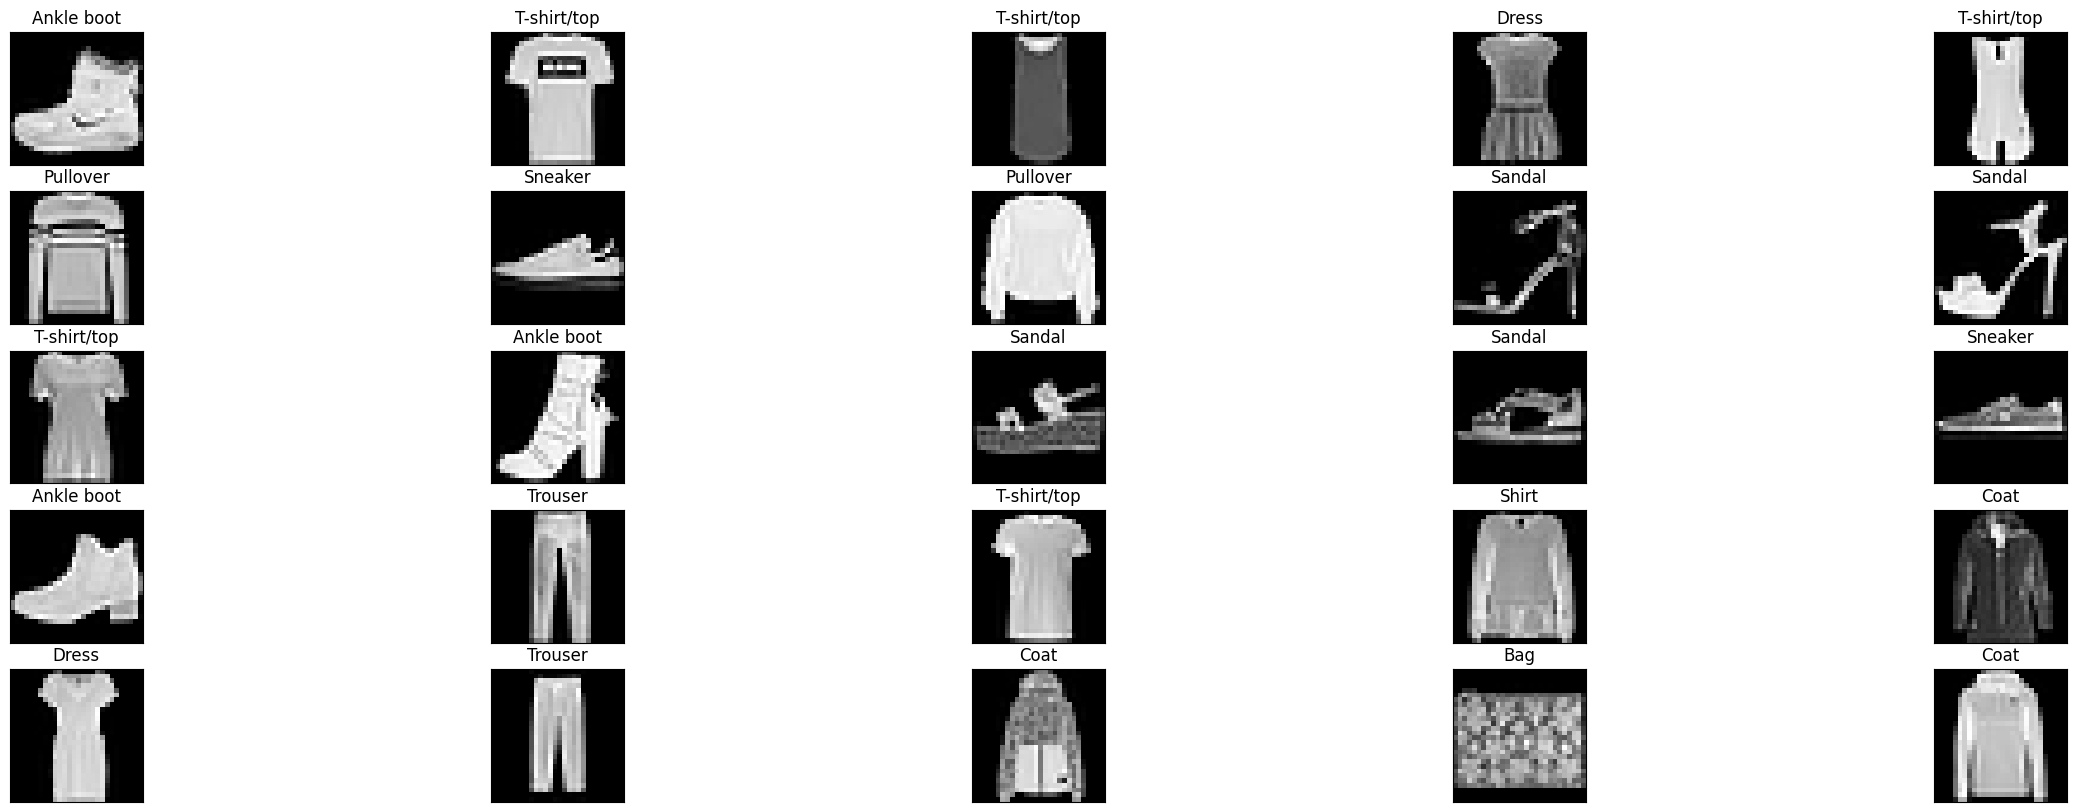

In [ ]:
fig = plt.figure(figsize=(30, 10))
for i in range(25):
    ax = fig.add_subplot(5, 5, i+1, xticks=[], yticks=[])
    ax.set_title(f"{labels[y_train[i]]}")
    ax.imshow(x_train[i], cmap="gray")

## Building and Training a Feedforward Neural Network


You will now build your first Neural Network.
In this part, we will construct a Feedforward Neural Network (FNN). To do this, we will first flatten the images into vectors so they can be treated like tabular data. Each pixel becomes one input feature, and the network will learn patterns by passing these inputs through hidden layers of connected neurons.

Our first NN will be a plain-vanilla network with a single hidden layer.

### Data Prep

The numbers range from 0 to 255. Let's normalize to the 0-1 range by dividing everything by 255.

In [ ]:
x_train = x_train / 255
x_test = x_test / 255

We also flatten the images.

In [ ]:
x_train = x_train.reshape(60000, 28*28).astype('float32')
x_test = x_test.reshape(10000, 28*28).astype('float32')
print(f"There are {x_train.shape[0]} rows and {x_train.shape[1]} columns in the training set")
print(f"There are {x_test.shape[0]} rows and {x_test.shape[1]} columns in the test set")

There are 60000 rows and 784 columns in the training set
There are 10000 rows and 784 columns in the test set


We now create a Feedforward Neural Network with one hidden layer. The hidden layer has 256 nodes, and the ReLU activation function applied on its output. Notice that the softmax activation function is applied at the output layer of the network, to create a probability distribution.

In [ ]:
model = keras.Sequential(
    [
        keras.Input(shape=(28*28,)),
        keras.layers.Dense(256, activation="relu", name="Hidden"),
        keras.layers.Dense(10, activation="softmax", name="Output"),
    ]
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden (Dense)                  │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

We now set optimization parameters. We compile the model using the appropriate loss function, the Adam optimizer with a learning rate of 0.001 and the appropriate metric (accuracy).

In [ ]:
opt = keras.optimizers.Adam(learning_rate=0.001)

model.compile(loss="sparse_categorical_crossentropy",
              optimizer=opt,
              metrics=["accuracy"])

We now set our batch size and desired number of epochs and we actually train our model on the training set.

In [ ]:
batch_size = 64
epochs = 10

model.fit(x_train, y_train, batch_size=batch_size, validation_split = 0.2,
          epochs=epochs)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7676 - loss: 0.6644 - val_accuracy: 0.8565 - val_loss: 0.4108
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8596 - loss: 0.3972 - val_accuracy: 0.8664 - val_loss: 0.3755
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8751 - loss: 0.3491 - val_accuracy: 0.8727 - val_loss: 0.3553
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8846 - loss: 0.3191 - val_accuracy: 0.8783 - val_loss: 0.3455
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8920 - loss: 0.2977 - val_accuracy: 0.8825 - val_loss: 0.3393
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8973 - loss: 0.2796 - val_accuracy: 0.8820 - val_loss: 0.3429
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9024 - loss: 0.2644 - val_accuracy: 0.8820 - val_loss: 0.3409
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9076 - loss: 0.2520 - val_accuracy: 0.

We now evaluate the model's performance on the training and the test set.

In [ ]:
# Evaluate the model on training data
train_loss, train_acc = model.evaluate(x_train, y_train)
print('Train accuracy:', train_acc)

# Evaluate the model on test data
test_loss, test_acc = model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9126 - loss: 0.2339
Train accuracy: 0.9085666537284851
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8746 - loss: 0.3544
Test accuracy: 0.8740000128746033


We add a second hidden layer of the same size (256 nodes) and a dropout layer between the first and the second hidden layer of the network.

In [ ]:
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import Input, Sequential

model = Sequential(
    [
        Input(shape=(28*28,)),
        Dense(256, activation="relu", name="Hidden_1"),
        Dropout(0.2),
        Dense(256, activation="relu", name="Hidden_2"),
        Dropout(0.2),
        Dense(10, activation="softmax", name="Output"),
    ]
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_1 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_2 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,322 (1.03 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

For Fashion MNIST, the **[state of the art (SOTA)](https://paperswithcode.com/sota/image-classification-on-fashion-mnist)** accuracy is **96.91%**!

Can we get closer to that?

## A Convolutional Neural Network




The last step is to build and train a Convolutional Neural Network (CNN).
Unlike feedforward networks, CNNs are designed to work directly with images. They use convolution and pooling layers to capture spatial patterns, such as edges or textures, which makes them especially effective for image classification tasks.

We will follow the same sequence of steps as we did above:


*   Data Prep
*   Define Model
*   Set Optimization Parameters
*   Train Model
*   Evaluate Model


The data has already been normalized so that the numbers are between 0 and 1. We don't need to do it again.

But we do need to reshape the image **vector** back into how it used to be: a 2D **matrix**.

In [ ]:
### DEFINE THE ORIGINAL IMAGE SHAPE ###

ORIG_IMG_SHAPE = 28

x_train = x_train.reshape(x_train.shape[0], ORIG_IMG_SHAPE, ORIG_IMG_SHAPE, 1)
x_test = x_test.reshape(x_test.shape[0], ORIG_IMG_SHAPE, ORIG_IMG_SHAPE, 1)

### Define Model

OK, we are ready to create our very first **Convolutional Neural Network (CNN)!**

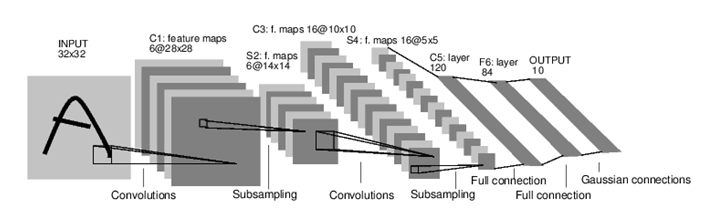

We define a simple CNN model. It consists of 2 Convolutional layers, the first layer has 32 kernels and the second one 16 kernels. The kernel size is 3x3. We use the ReLU activation function. After each Convolutional layer, we are also using a max pooling layer, with pool size of 2x2.
For the fully connected part of the model, we use one hidden layer and one output layer. The hidden layer has 128 nodes.

In [ ]:
# Define a simple CNN model
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28,28,1)))
model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

We set the same optimization parameters as earlier, as well as batch size and number of epochs.

In [ ]:
opt = keras.optimizers.Adam(learning_rate=0.001)

# Compile the model with a loss function and an optimizer
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

batch_size = 64
n_epochs=10

We now train our model and plot the validation and training loss across the different epochs.

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - accuracy: 0.7420 - loss: 0.7241 - val_accuracy: 0.8737 - val_loss: 0.3625
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 51ms/step - accuracy: 0.8719 - loss: 0.3589 - val_accuracy: 0.8888 - val_loss: 0.3150
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 53ms/step - accuracy: 0.8903 - loss: 0.3050 - val_accuracy: 0.8959 - val_loss: 0.2931
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.9031 - loss: 0.2690 - val_accuracy: 0.8992 - val_loss: 0.2790
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step - accuracy: 0.9139 - loss: 0.2396 - val_accuracy: 0.8988 - val_loss: 0.2805
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step - accuracy: 0.9208 - loss: 0.2145 - val_accuracy: 0.9011 - val_loss: 0.2839
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 54ms/step - accuracy: 0.9297 - loss: 0.1898 - val_accuracy: 0.8993 - val_loss: 0.2926
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 51ms/step - accuracy: 0.9389 - loss: 0.1677 - 

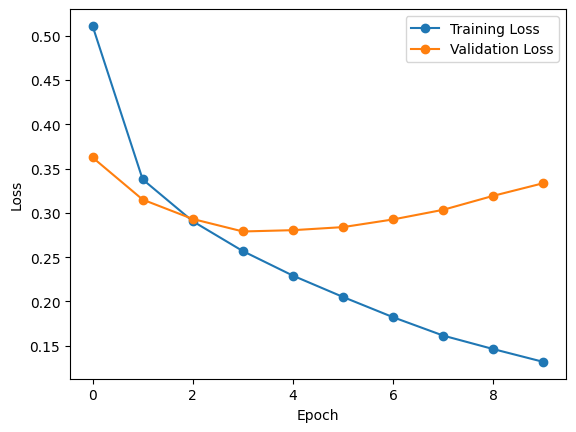

In [ ]:
history = model.fit(x_train,
         y_train,
         batch_size=batch_size,
         epochs=n_epochs,
         validation_split=0.2)

plt.plot(history.history['loss'], '-o', label='Training Loss')
plt.plot(history.history['val_loss'], '-o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


We again evaluate our model on the test set.

In [ ]:
# Evaluate the model on test data
test_loss, test_acc = model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8919 - loss: 0.3749
Test accuracy: 0.8932999968528748


The **confusion matrix** is a good way to get a complete picture of our performance.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


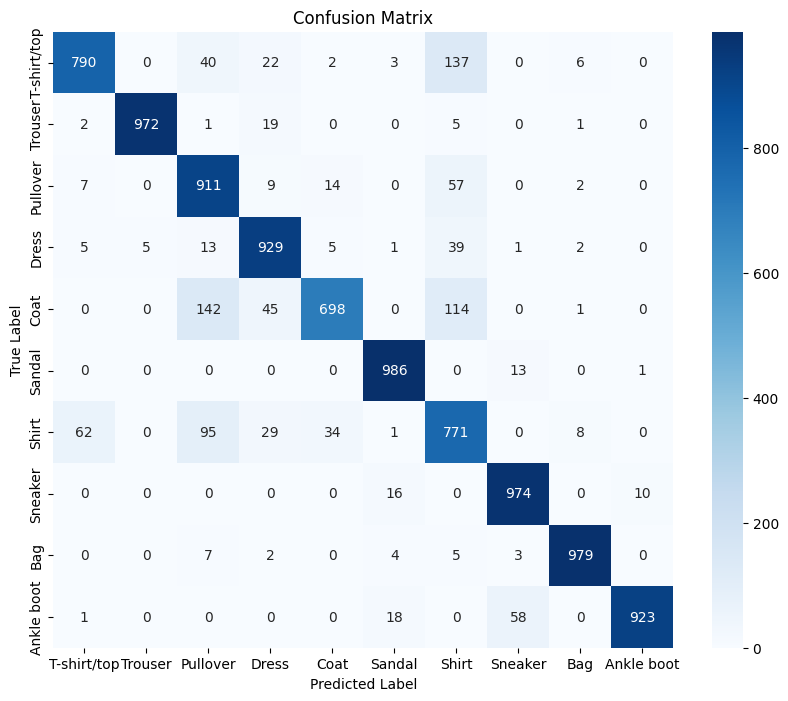

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions
y_pred = model.predict(x_test)
y_pred_labels = np.argmax(y_pred, axis=1)

# If y_test is already integer labels:
cm = confusion_matrix(y_test, y_pred_labels)

# Plot
def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

plot_confusion_matrix(cm, labels)